In [309]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.lines import Line2D
from IPython.display import display

In [310]:
def read_file(path, cols_names):
    return pd.read_csv(path, header=None, names=cols_names)

In [311]:
class SpectralClustering:
    def __init__(self, data, k, sigma):
        self.data = data
        self.k = k
        self.sigma = sigma

    def __compute_distances(self, X, sigma):
        X_ext = X.reshape(-1,1,X.shape[1])
        norm = np.square(X_ext - X).sum(axis=2)
        anti_diagonal = 1 - np.identity(X.shape[0])
        return np.exp(-norm/(2* (sigma ** 2) )) * anti_diagonal
    
    def plot_dataset(self):
        plt.figure(figsize=(5,5))
        plt.scatter(self.data[:,0], self.data[:,1], s=10)
        plt.grid(visible=True, alpha=0.1)
        return
    
    def plot_heatmap(self):
        if not hasattr(self,'W'):
            self.W = self.__compute_distances(self.data, self.sigma)
        plt.figure()
        plt.imshow(self.W)
        plt.colorbar()
        return

    def get_adjacency_matrix(self):
        if not hasattr(self,'W'):
            self.W = self.__compute_distances(self.data, self.sigma)
        return self.W

    def get_KNN(self): 
        if not hasattr(self,'W'):
            self.W = self.__compute_distances(self.data, self.sigma)

        if not hasattr(self,'KNN'):
            self.KNN = np.sort(self.W, axis = 1)[:, :-(self.k+1):-1]

        return self.KNN

    def get_degree_matrix(self):
        if not hasattr(self,'W'):
            self.W = self.__compute_distances(self.data, self.sigma)

        if not hasattr(self,'D'):
            self.D = self.W.sum(axis=1) * np.identity(self.W.shape[0])

        return self.W.sum(axis=1) * np.identity(self.W.shape[0])

    def get_laplacian_matrix(self):
        if not hasattr(self,'W'):
            self.W = self.__compute_distances(self.data, self.sigma)

        if not hasattr(self,'D'):
            self.D = self.W.sum(axis=1) * np.identity(self.W.shape[0])

        if not hasattr(self,'L'):
            self.L = self.D - self.W           

        return self.L
    

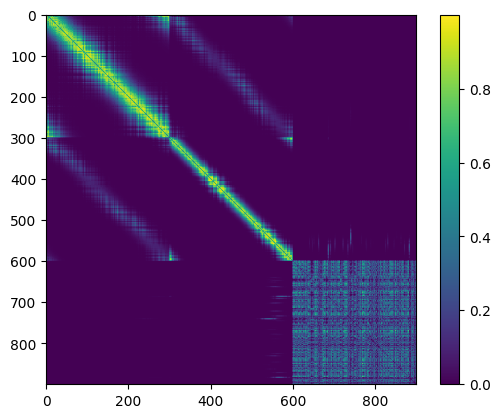

In [312]:
circle_df = read_file("Circle.csv", ['x', 'y'])

circle_ds = circle_df.values

circle_sc = SpectralClustering(circle_ds, 10, 1)

circle_W = circle_sc.get_adjacency_matrix() 
circle_KNN = circle_sc.get_KNN()
circle_D = circle_sc.get_degree_matrix()
circle_L = circle_sc.get_laplacian_matrix()

# circle_sc.plot_dataset()
circle_sc.plot_heatmap()

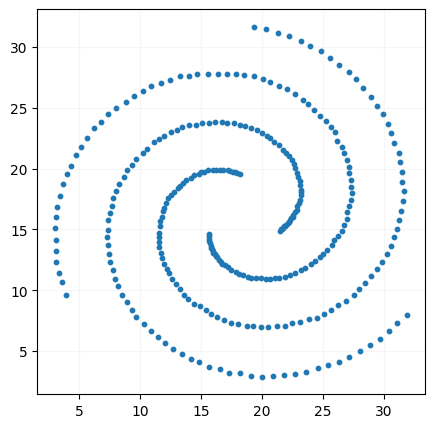

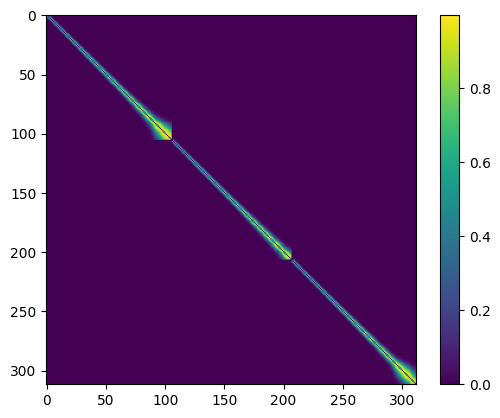

In [313]:
spiral_df = read_file("Spiral.csv", ['x', 'y', 'target'])
spiral_ds = spiral_df.loc[:, ['x','y']].values

spiral_sc = SpectralClustering(spiral_ds, 10, 1)

spiral_W = spiral_sc.get_adjacency_matrix() 
spiral_KNN = spiral_sc.get_KNN()
spiral_D = spiral_sc.get_degree_matrix()
spiral_L = spiral_sc.get_laplacian_matrix()

spiral_sc.plot_dataset()
spiral_sc.plot_heatmap()